### Распределение эмбеддингов текстов. 
Энкодер: e5-base-v2

In [1]:
SEED = 42
ENCODER = "intfloat/e5-base-v2"
MAX_HUMAN_SAMPLES = 10000

MAX_VIS_SAMPLES = 2000

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.decomposition import PCA
from scipy.special import softmax
from random import sample
from scipy.stats import skew, kurtosis
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

In [3]:
# https://huggingface.co/intfloat/e5-base-v2

def average_pool(last_hidden_states, attention_mask):
    last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]

    
def get_embeddings(tokenizer, model, df, batch_size=16, device=None):
    if device is None:
        device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

    model.to(device)
    model.eval()
    all_embeddings = []

    for i in tqdm(range(0, len(df), batch_size)):
        batch_texts = list(map(lambda text: "passage: " + text, df[i:i + batch_size].tolist()))
        encoded_input = tokenizer(
            batch_texts,
            max_length=512,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )

        encoded_input = {k: v.to(device) for k, v in encoded_input.items()}

        with torch.no_grad():
            model_output = model(**encoded_input)
            embeddings = average_pool(model_output.last_hidden_state, encoded_input['attention_mask'])
        
        all_embeddings.append(embeddings.cpu())

        if device.type == "mps":
            torch.mps.empty_cache()

    all_embeddings = torch.cat(all_embeddings, dim=0)
    return all_embeddings

In [4]:
sns.set(style="whitegrid")

def subsample(X_h, X_ai, max_samples):
    idx_h = list(range(len(X_h)))
    idx_ai = list(range(len(X_ai)))

    if len(idx_h) > max_samples // 2:
        idx_h = sample(idx_h, max_samples // 2)
    if len(idx_ai) > max_samples // 2:
        idx_ai = sample(idx_ai, max_samples // 2)

    X = np.vstack([X_h[idx_h], X_ai[idx_ai]])
    y = np.concatenate([np.zeros(len(idx_h)), np.ones(len(idx_ai))])

    return X, y


def plot_mahalanobis_distributions(scores_human, scores_ai, name):
    plt.figure(figsize=(8, 5))

    all_scores = np.concatenate([scores_human, scores_ai])
    bins = np.histogram_bin_edges(all_scores, bins="auto")

    plt.hist(scores_human, bins=bins, density=True, alpha=0.6, label="Человек")
    plt.hist(scores_ai, bins=bins, density=True, alpha=0.6, label="ИИ")

    plt.title(f"Распределение расстояния Махаланобиса (набор '{name}')")
    plt.xlabel("Квадрат расстояния Махаланобиса")
    plt.ylabel("Плотность")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    plt.show()


def plot_roc_curve(y_true, scores, roc_auc, name):
    fpr, tpr, _ = roc_curve(y_true, scores)
    
    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate TPR")
    plt.title(f"ROC-кривая ('{name}')")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    plt.show()


def plot_pca_projection(X_human, X_ai, name):
    X, y = subsample(X_human, X_ai, MAX_VIS_SAMPLES)
    X_2d = PCA(n_components=2, random_state=SEED).fit_transform(X)

    plt.figure(figsize=(8, 5))
    scatter = sns.scatterplot(
        x=X_2d[:, 0], y=X_2d[:, 1],
        hue=y, palette={0: "blue", 1: "orange"},
        alpha=0.5, s=35
    )
    plt.title(f"Проекция PCA (dataset '{name}')")

    handles, _ = scatter.get_legend_handles_labels()
    plt.legend(handles=handles, labels=["Человек", "ИИ"])
    plt.tight_layout()
    
    plt.show()


def print_header(title, char="="):
    print(f"\n{char * 100}")
    print(title)
    print(f"{char * 100}")


def print_subheader(title):
    print(f"\n--- {title} ---")


def print_kv(key, value, width=35):
    print(f"{key:<{width}}: {value}")


def covariance_spectrum(cov, top_k=100):
    C = cov.covariance_
    
    eigvals = np.linalg.eigvalsh(C)
    eigvals = eigvals[::-1]
    
    explained = eigvals / eigvals.sum()
    cumulative = np.cumsum(explained)

    fig, ax = plt.subplots(2, 1, figsize=(8, 8))

    ax[0].bar(range(1, top_k + 1), explained[:top_k])
    ax[0].set_title("Объясненная дисперсия (первые компоненты)")
    ax[0].set_xlabel("Номер компоненты")
    ax[0].set_ylabel("Доля объясненной дисперсии")

    ax[1].plot(range(1, top_k + 1), cumulative[:top_k], marker="o")
    ax[1].axhline(0.9, color="r", linestyle="--", label="90%")
    ax[1].axhline(0.95, color="g", linestyle="--", label="95%")
    ax[1].set_title("Накопленная объясненная дисперсия")
    ax[1].set_xlabel("Число компонент")
    ax[1].set_ylabel("Накопленная доля дисперсии")
    ax[1].legend()

    plt.tight_layout()
    plt.show()
    

def print_mahalanobis_stats(scores, label, width=50, precision=4):
    stats = {
        "Среднее": scores.mean(),
        "Стд. отклонение": scores.std(),
        "Асимметрия": skew(scores),
        "Эксцесс": kurtosis(scores),
        "95% квантиль": np.quantile(scores, 0.95),
        "99% квантиль": np.quantile(scores, 0.99),
    }
    
    print(f"Статистики расстояния Махаланобиса ({label})")
    print("=" * width)
    for k, v in stats.items():
        print(f"{k:<18s} | {v:>{width-22}.{precision}f}")
    print("=" * width)
    print("")


def print_norm_stats(X, precision=4):
    norms = np.linalg.norm(X, axis=1)
    
    stats = {
        "Среднее значение нормы": norms.mean(),
        "Стандартное отклонение": norms.std(),
    }
        
    print("Статистики норм векторов")
    print("=" * 32)
    for k, v in stats.items():
        print(f"{k:<24s}: {v:.{precision}f}")
    print("=" * 32)
    print("")

In [5]:
human_df = (
    pd.read_csv("../datasets/ivy_panda_essays.csv", encoding="utf-8")
    .assign(label=0)[["text", "label"]]
    .reset_index(drop=True)
)

if MAX_HUMAN_SAMPLES is not None:
    human_df = human_df.sample(n=MAX_HUMAN_SAMPLES, random_state=SEED)

print(f"Живых текстов: {len(human_df)}")

Живых текстов: 10000


In [6]:
filenames = {
    "Mistral 7B 1": "../datasets/mistral_essays_1.csv",
    "Mistral 7B 2": "../datasets/mistral_essays_2.csv",
    "Mistral 7B 3": "../datasets/mistral_essays_3.csv",
    "Mistral 7B 4": "../datasets/mistral_essays_4.csv",
    "Mistral 7B 5": "../datasets/mistral_essays_5.csv",
    "Llama 3 13B 1": "../datasets/llama_essays_1.csv",
    "Llama 3 13B 2": "../datasets/llama_essays_2.csv",
    "Llama 3 13B 3": "../datasets/llama_essays_3.csv",
    "Llama 3 13B 4": "../datasets/llama_essays_4.csv",
    "Llama 3 13B 5": "../datasets/llama_essays_5.csv",
    "DeepSeek V3.2 1": "../datasets/deepseek_essays_1.csv",
    "DeepSeek V3.2 2": "../datasets/deepseek_essays_2.csv",
    "DeepSeek V3.2 3": "../datasets/deepseek_essays_3.csv",
    "DeepSeek V3.2 4": "../datasets/deepseek_essays_4.csv",
    "DeepSeek V3.2 5": "../datasets/deepseek_essays_5.csv",
    "ChatGPT 1": "../datasets/chatgpt_essays_1.csv",
    "ChatGPT 2": "../datasets/chatgpt_essays_2.csv",
    "ChatGPT 3": "../datasets/chatgpt_essays_3.csv",
    "ChatGPT 4": "../datasets/chatgpt_essays_4.csv",
    "ChatGPT 5": "../datasets/chatgpt_essays_5.csv",
}

ai_datasets = {}
for name, fn in filenames.items():
    df = pd.read_csv(fn, encoding="utf-8").assign(label=1)[["text", "label"]].reset_index(drop=True)
    ai_datasets[name] = df
    print(f"Загружен датасет '{name}'. {len(df)} записей")

Загружен датасет 'Mistral 7B 1'. 1500 записей
Загружен датасет 'Mistral 7B 2'. 1500 записей
Загружен датасет 'Mistral 7B 3'. 1500 записей
Загружен датасет 'Mistral 7B 4'. 1500 записей
Загружен датасет 'Mistral 7B 5'. 1500 записей
Загружен датасет 'Llama 3 13B 1'. 999 записей
Загружен датасет 'Llama 3 13B 2'. 1000 записей
Загружен датасет 'Llama 3 13B 3'. 994 записей
Загружен датасет 'Llama 3 13B 4'. 997 записей
Загружен датасет 'Llama 3 13B 5'. 999 записей
Загружен датасет 'DeepSeek V3.2 1'. 3000 записей
Загружен датасет 'DeepSeek V3.2 2'. 3000 записей
Загружен датасет 'DeepSeek V3.2 3'. 2999 записей
Загружен датасет 'DeepSeek V3.2 4'. 3000 записей
Загружен датасет 'DeepSeek V3.2 5'. 3000 записей
Загружен датасет 'ChatGPT 1'. 2000 записей
Загружен датасет 'ChatGPT 2'. 2000 записей
Загружен датасет 'ChatGPT 3'. 2000 записей
Загружен датасет 'ChatGPT 4'. 2000 записей
Загружен датасет 'ChatGPT 5'. 2000 записей



ENCODER: intfloat/e5-base-v2


100%|█████████████████████████████████████████| 625/625 [07:52<00:00,  1.32it/s]


Статистики норм векторов
Среднее значение нормы  : 11.0367
Стандартное отклонение  : 0.3309

Эмбеддинги живых текстов (train)   : 7000
Эмбеддинги живых текстов (test)    : 3000


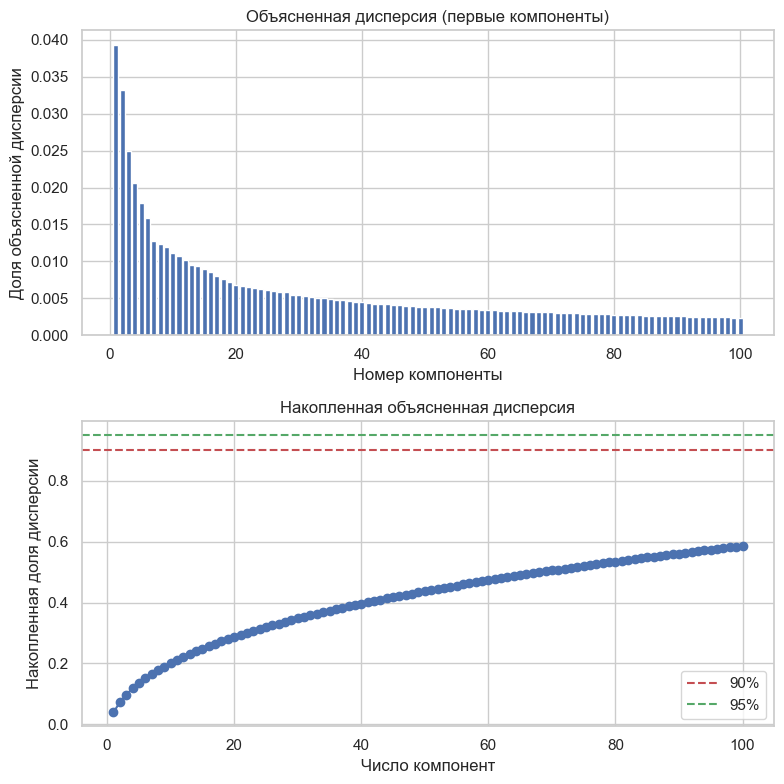


Набор: Mistral 7B 1
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:08<00:00,  1.38it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.4545
Стд. отклонение    |                     127.1086
Асимметрия         |                       0.6860
Эксцесс            |                       0.6683
95% квантиль       |                     953.7444
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     885.4416
Стд. отклонение    |                     163.0291
Асимметрия         |                       0.9350
Эксцесс            |                       1.6508
95% квантиль       |                    1176.2369
99% квантиль       |                    1385.4293

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.7992
PR-AUC                             : 0.7885


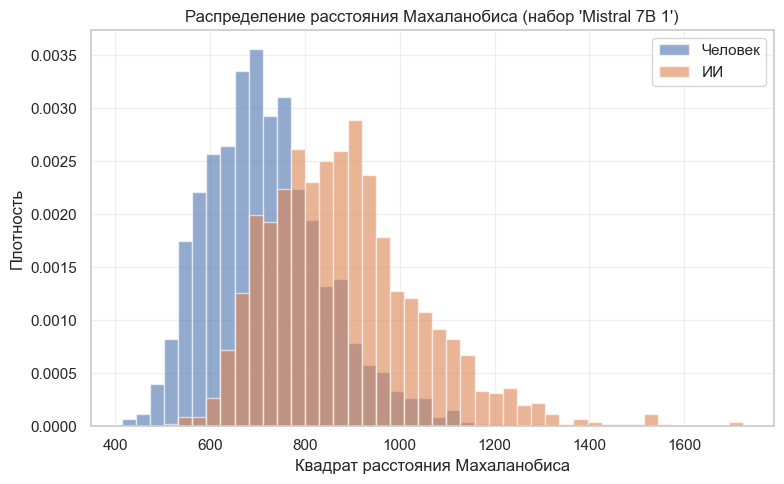

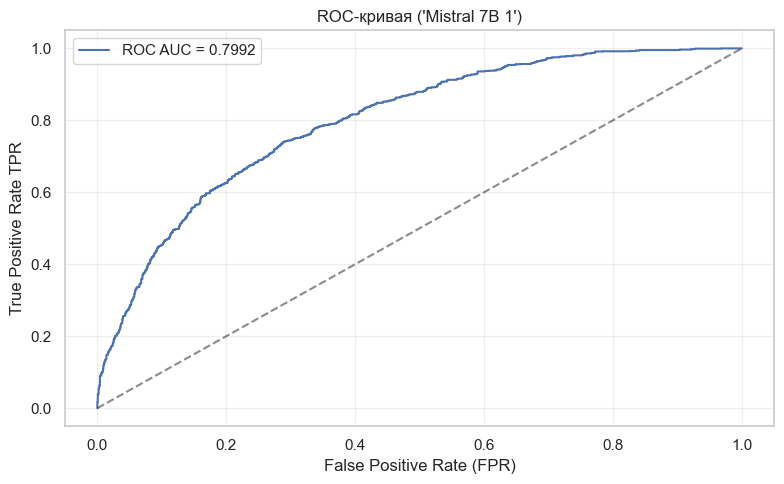

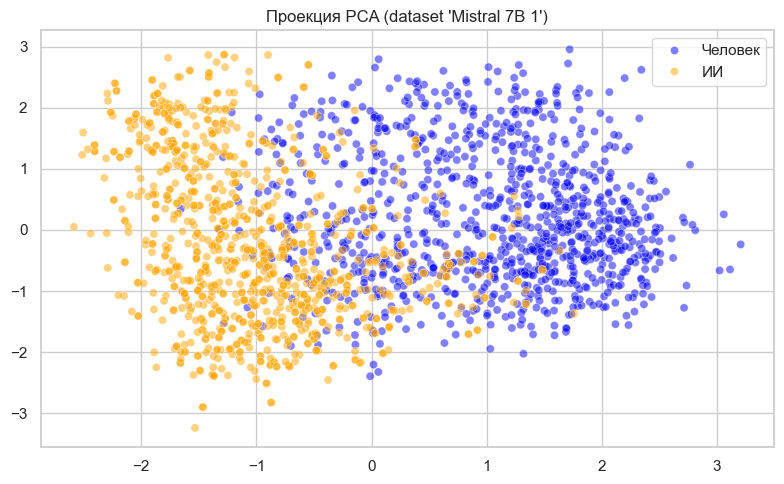


Набор: Mistral 7B 2
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:08<00:00,  1.37it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.4545
Стд. отклонение    |                     127.1086
Асимметрия         |                       0.6860
Эксцесс            |                       0.6683
95% квантиль       |                     953.7444
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     831.0027
Стд. отклонение    |                     141.0478
Асимметрия         |                       0.6687
Эксцесс            |                       0.6511
95% квантиль       |                    1092.4432
99% квантиль       |                    1229.7930

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.7298
PR-AUC                             : 0.7071


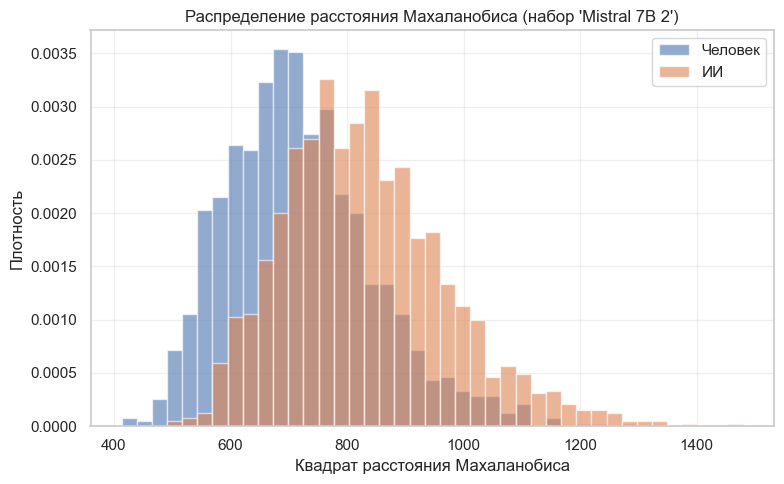

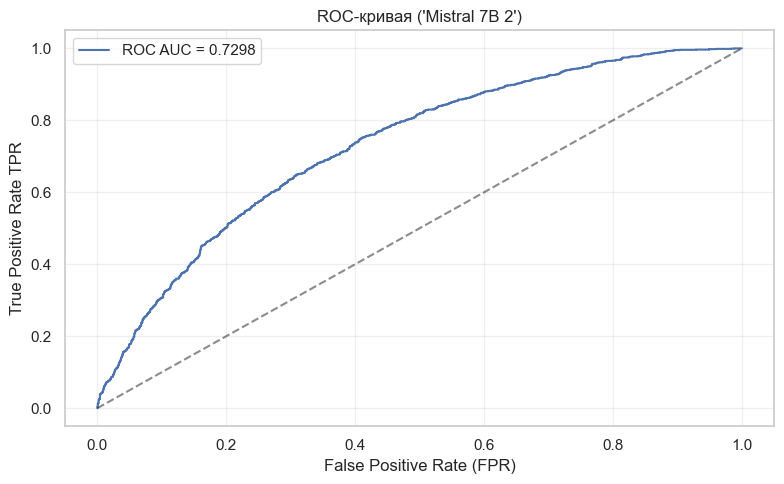

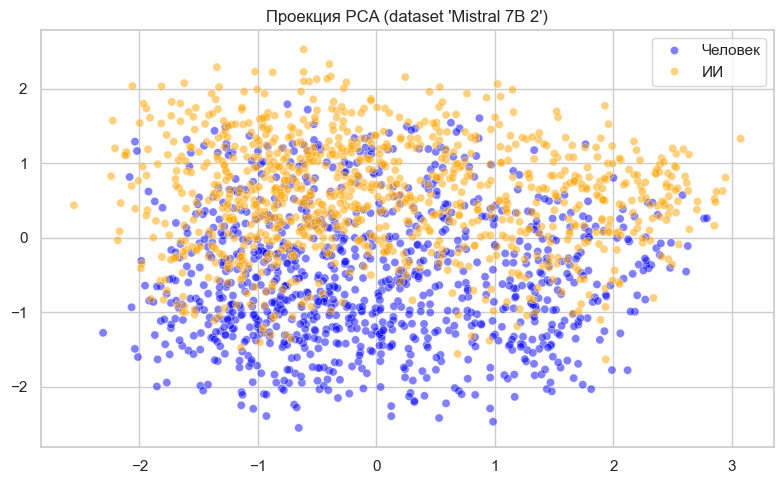


Набор: Mistral 7B 3
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:08<00:00,  1.37it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.4545
Стд. отклонение    |                     127.1086
Асимметрия         |                       0.6860
Эксцесс            |                       0.6683
95% квантиль       |                     953.7444
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     858.9581
Стд. отклонение    |                     162.2266
Асимметрия         |                       1.0125
Эксцесс            |                       1.9218
95% квантиль       |                    1148.5588
99% квантиль       |                    1317.6267

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.7592
PR-AUC                             : 0.7492


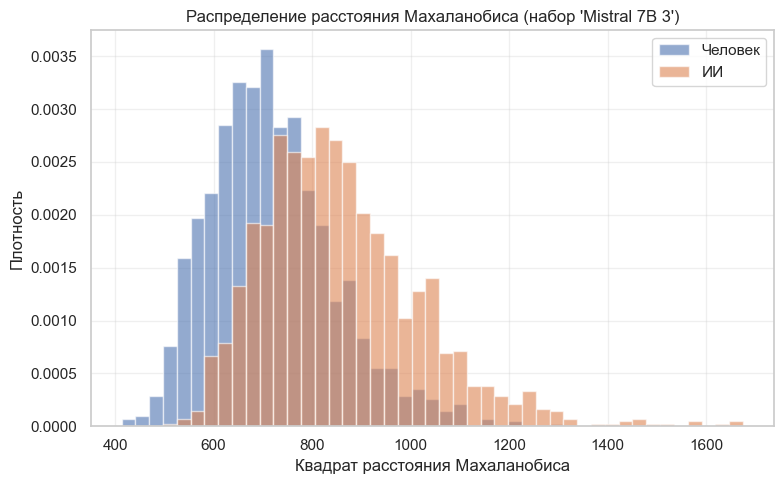

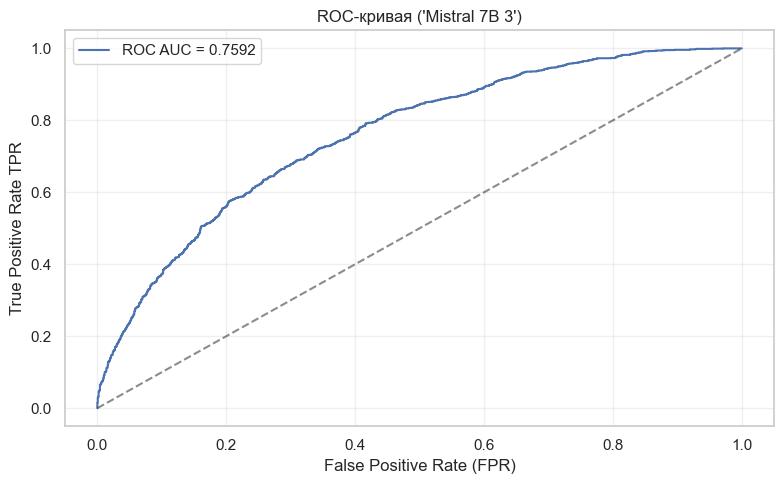

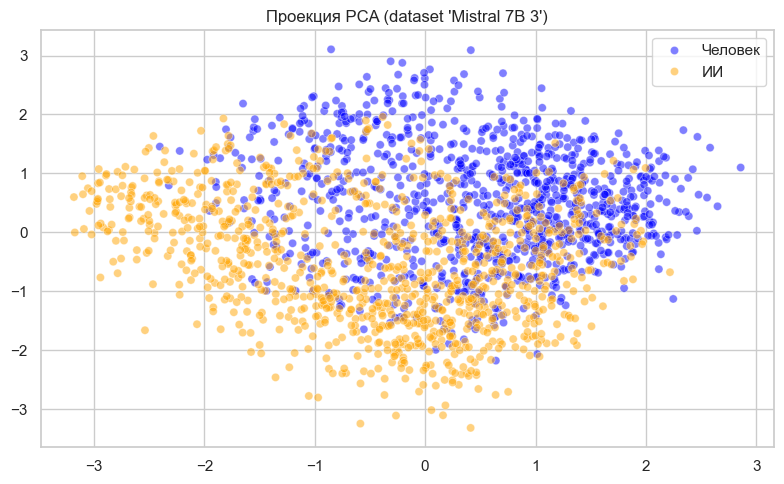


Набор: Mistral 7B 4
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:09<00:00,  1.36it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.4545
Стд. отклонение    |                     127.1086
Асимметрия         |                       0.6860
Эксцесс            |                       0.6683
95% квантиль       |                     953.7444
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     841.4163
Стд. отклонение    |                     146.2451
Асимметрия         |                       0.5935
Эксцесс            |                       0.4906
95% квантиль       |                    1111.7770
99% квантиль       |                    1250.6983

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.7431
PR-AUC                             : 0.7260


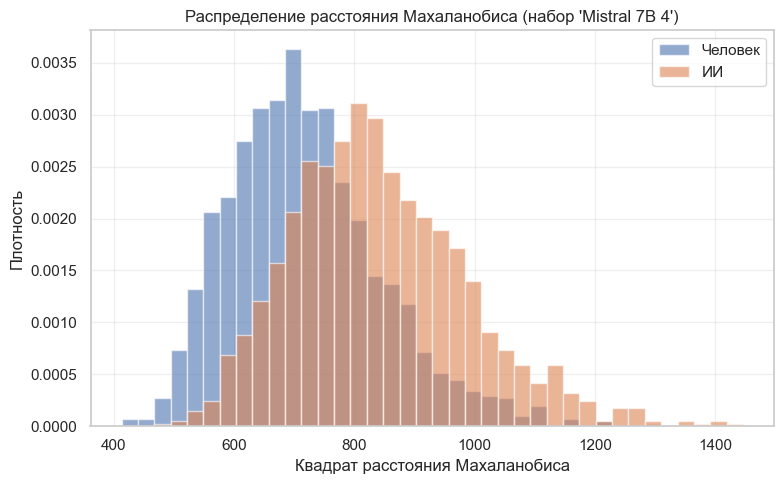

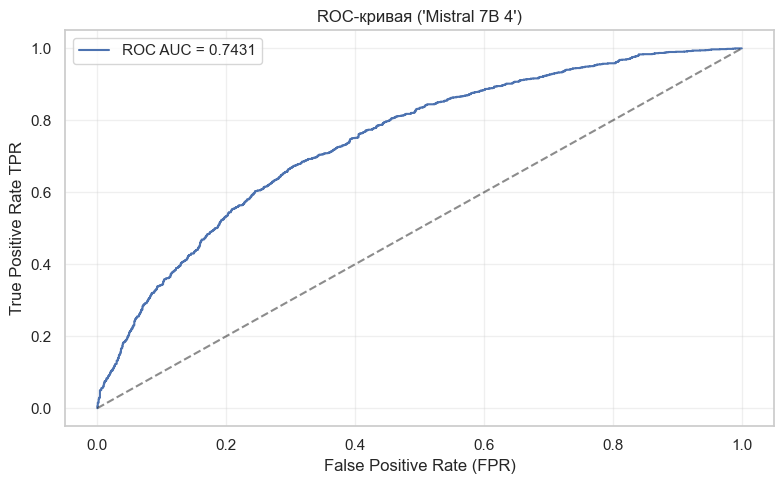

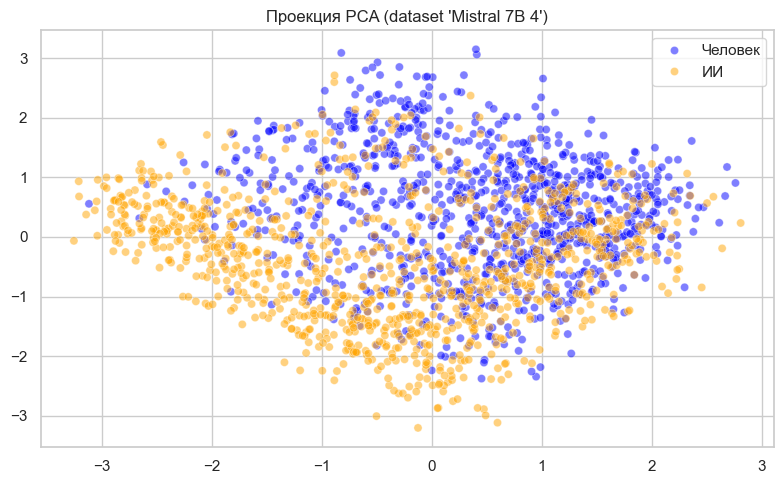


Набор: Mistral 7B 5
----------------------------------------


100%|███████████████████████████████████████████| 94/94 [01:07<00:00,  1.39it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.4545
Стд. отклонение    |                     127.1086
Асимметрия         |                       0.6860
Эксцесс            |                       0.6683
95% квантиль       |                     953.7444
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     811.6211
Стд. отклонение    |                     119.0496
Асимметрия         |                       0.5557
Эксцесс            |                       0.3442
95% квантиль       |                    1023.3448
99% квантиль       |                    1136.0197

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1500
ROC-AUC                            : 0.7144
PR-AUC                             : 0.6664


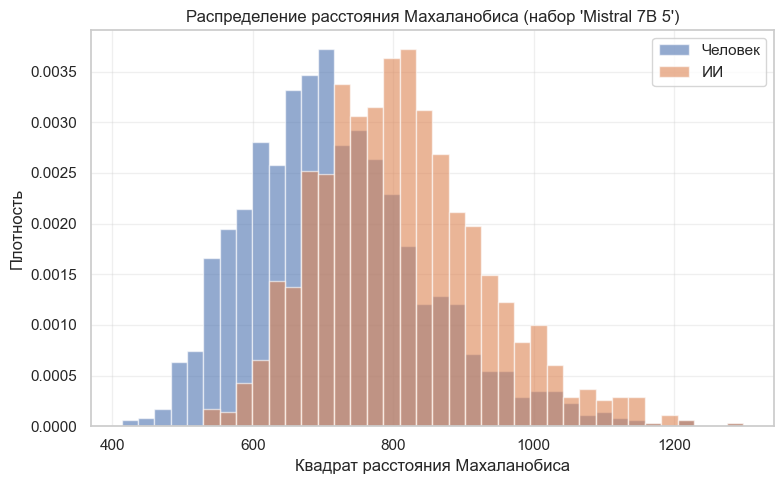

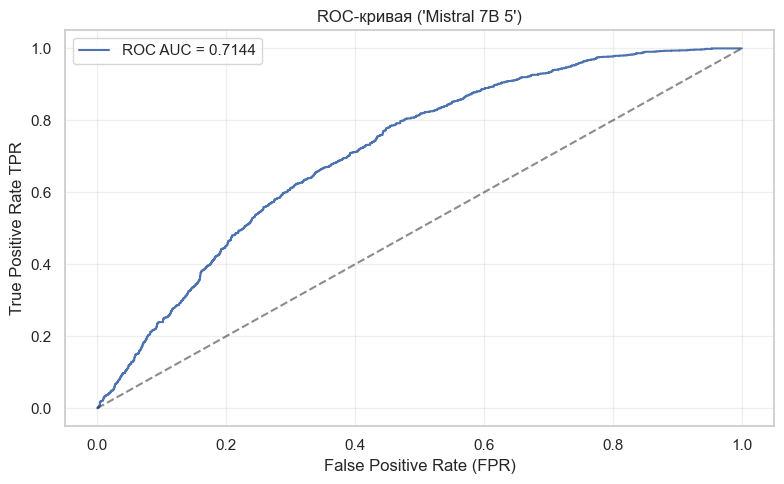

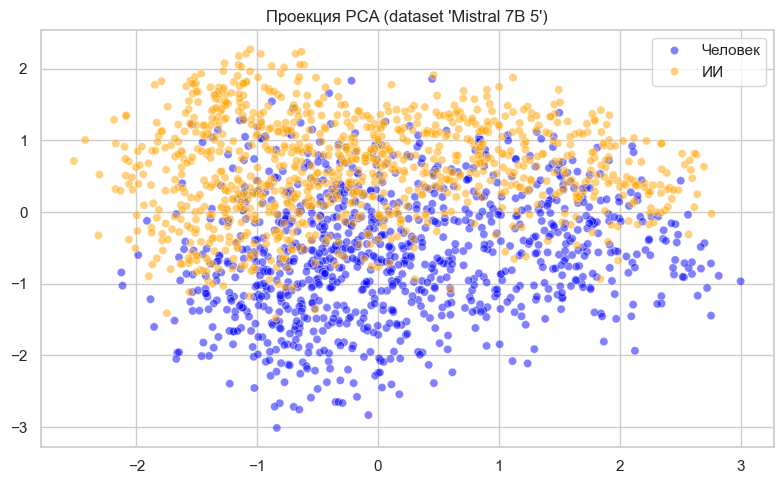


Набор: Llama 3 13B 1
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:45<00:00,  1.38it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.2199
Стд. отклонение    |                     125.9201
Асимметрия         |                       0.5950
Эксцесс            |                       0.4335
95% квантиль       |                     947.8647
99% квантиль       |                    1052.8827

Статистики расстояния Махаланобиса (ии)
Среднее            |                     935.9043
Стд. отклонение    |                     176.4897
Асимметрия         |                       1.0644
Эксцесс            |                       2.3322
95% квантиль       |                    1250.9293
99% квантиль       |                    1464.5135

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 999
ROC-AUC                            : 0.8548
PR-AUC                             : 0.8499


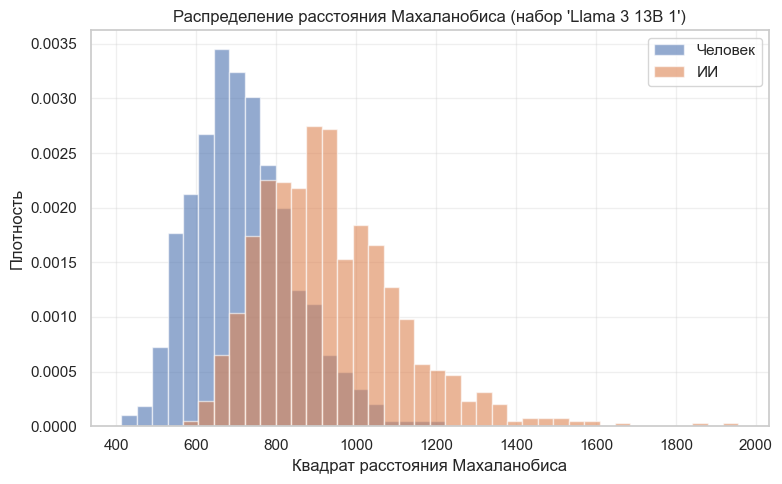

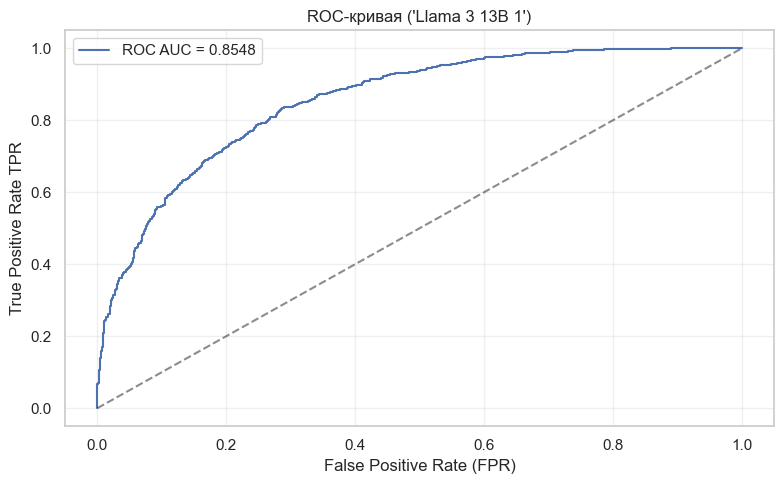

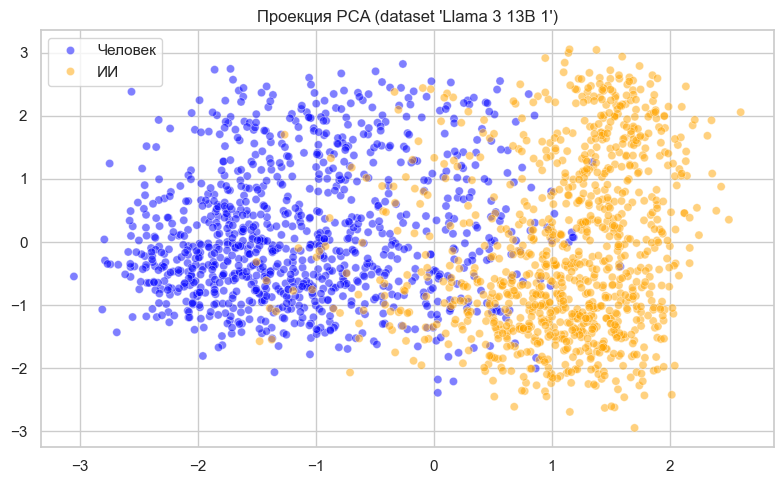


Набор: Llama 3 13B 2
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:45<00:00,  1.37it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.1367
Стд. отклонение    |                     125.8846
Асимметрия         |                       0.5966
Эксцесс            |                       0.4357
95% квантиль       |                     947.7189
99% квантиль       |                    1052.7729

Статистики расстояния Махаланобиса (ии)
Среднее            |                     856.9064
Стд. отклонение    |                     142.1094
Асимметрия         |                       0.8788
Эксцесс            |                       1.4317
95% квантиль       |                    1122.6109
99% квантиль       |                    1294.0032

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 1000
ROC-AUC                            : 0.7748
PR-AUC                             : 0.7521


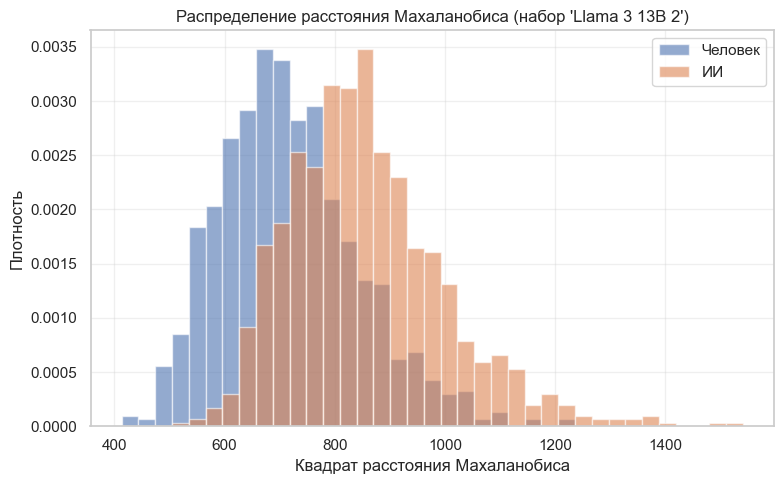

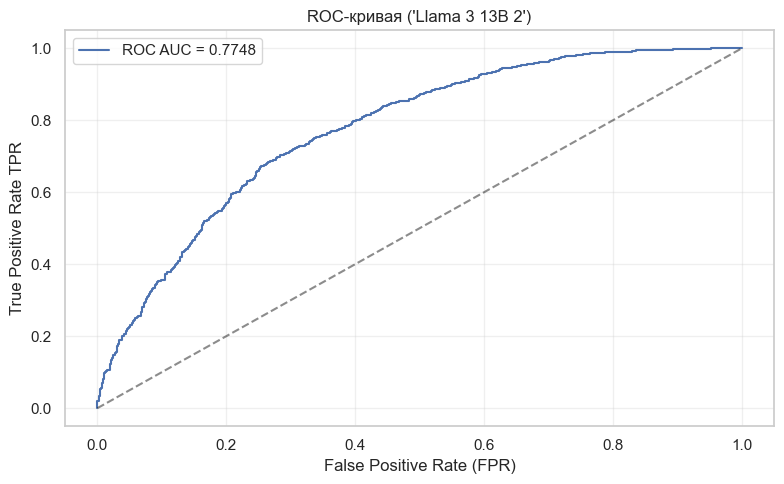

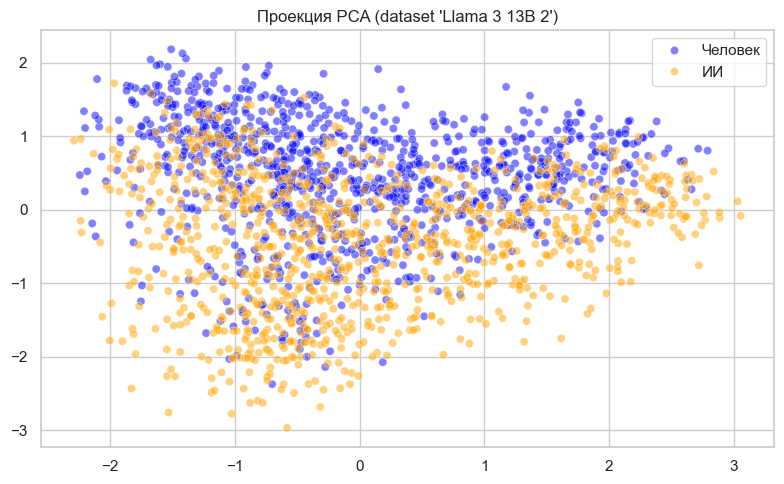


Набор: Llama 3 13B 3
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:44<00:00,  1.42it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.4076
Стд. отклонение    |                     126.0879
Асимметрия         |                       0.5937
Эксцесс            |                       0.4257
95% квантиль       |                     948.5938
99% квантиль       |                    1053.4319

Статистики расстояния Махаланобиса (ии)
Среднее            |                     916.3040
Стд. отклонение    |                     188.3259
Асимметрия         |                       1.6937
Эксцесс            |                       9.4568
95% квантиль       |                    1232.2707
99% квантиль       |                    1515.9480

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 994
ROC-AUC                            : 0.8229
PR-AUC                             : 0.8239


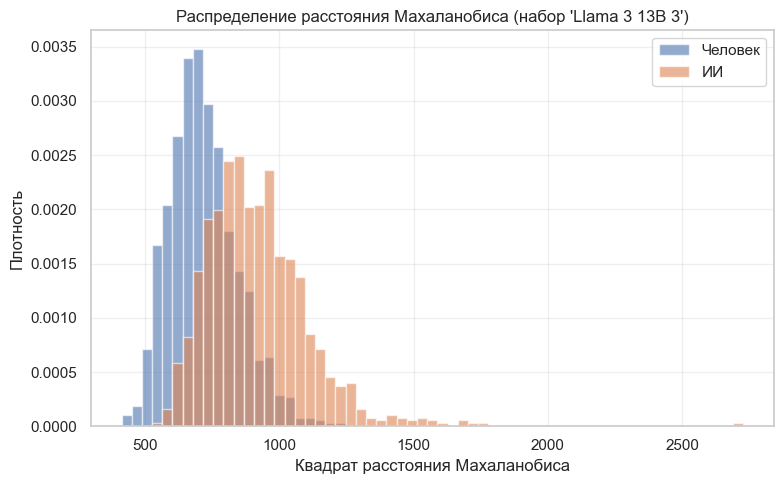

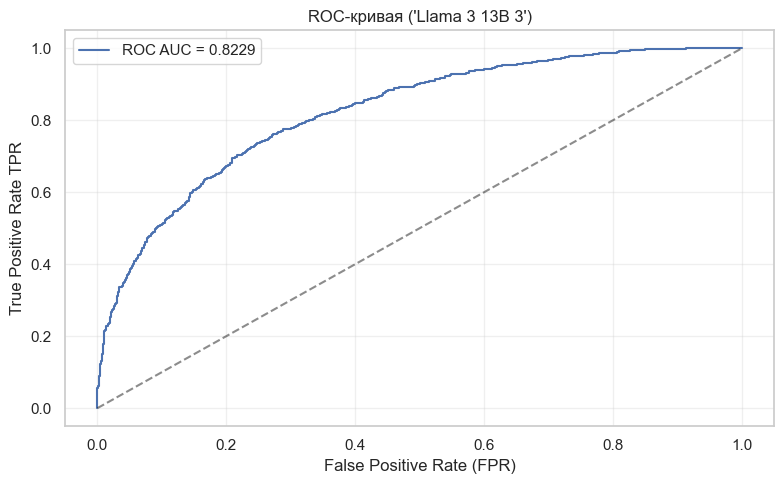

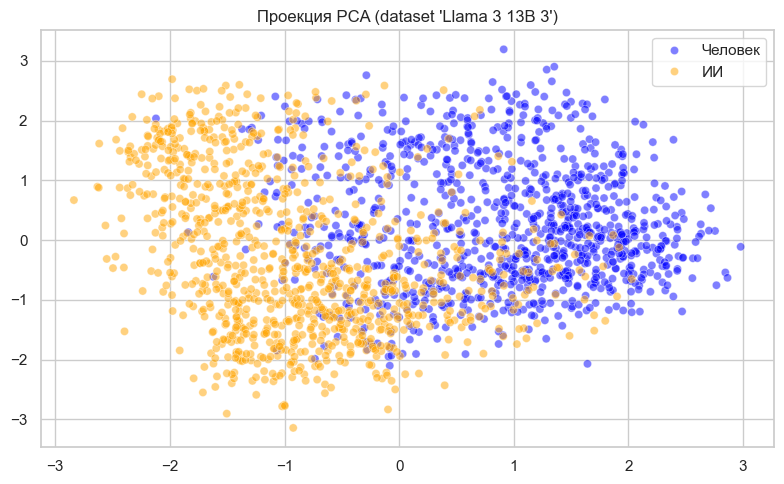


Набор: Llama 3 13B 4
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:46<00:00,  1.36it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.3748
Стд. отклонение    |                     125.9385
Асимметрия         |                       0.5945
Эксцесс            |                       0.4326
95% квантиль       |                     948.1564
99% квантиль       |                    1053.1024

Статистики расстояния Махаланобиса (ии)
Среднее            |                     878.5783
Стд. отклонение    |                     163.6530
Асимметрия         |                       0.9860
Эксцесс            |                       1.8581
95% квантиль       |                    1177.1634
99% квантиль       |                    1433.6308

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 997
ROC-AUC                            : 0.7885
PR-AUC                             : 0.7815


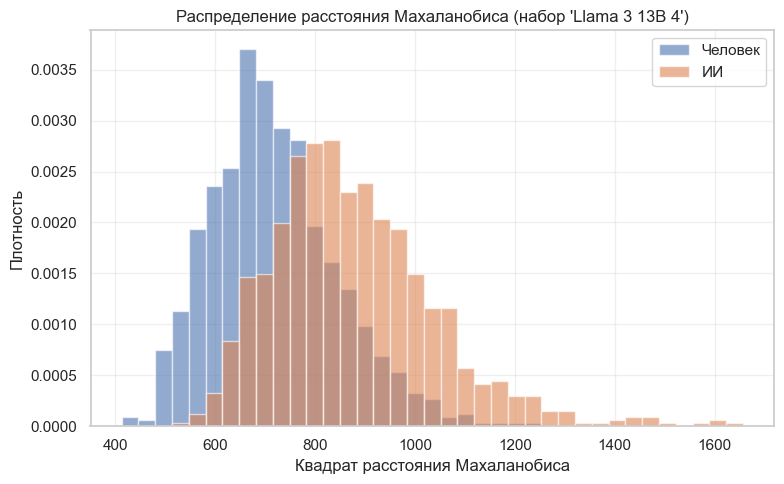

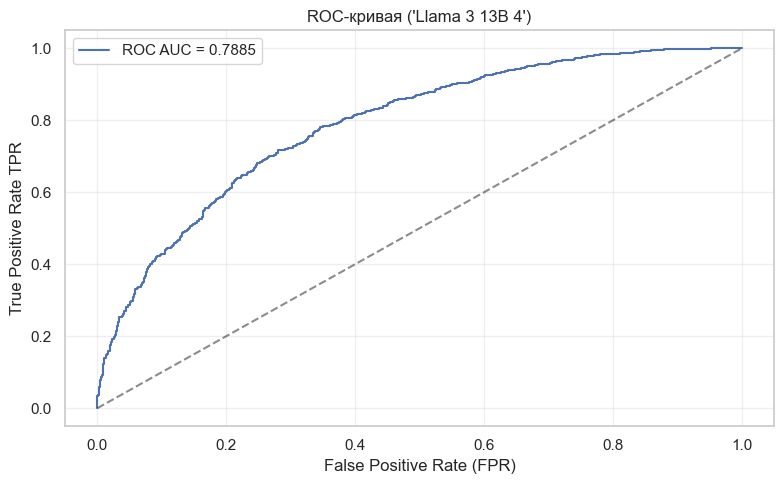

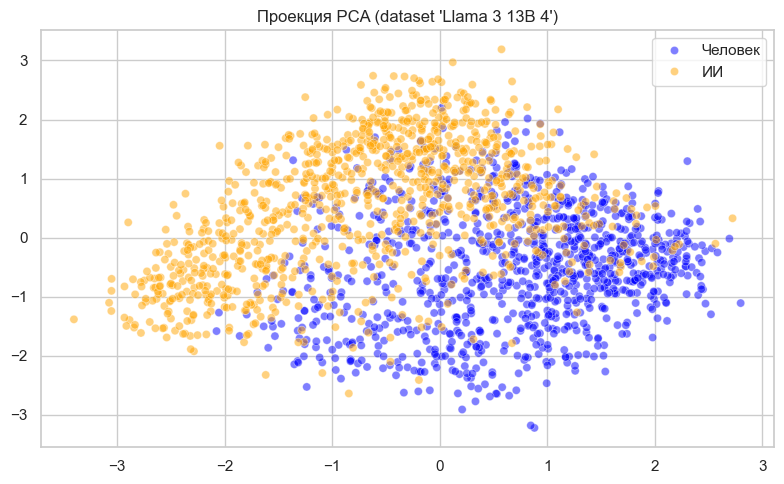


Набор: Llama 3 13B 5
----------------------------------------


100%|███████████████████████████████████████████| 63/63 [00:44<00:00,  1.41it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     718.2199
Стд. отклонение    |                     125.9201
Асимметрия         |                       0.5950
Эксцесс            |                       0.4335
95% квантиль       |                     947.8647
99% квантиль       |                    1052.8827

Статистики расстояния Махаланобиса (ии)
Среднее            |                     870.1902
Стд. отклонение    |                     156.4966
Асимметрия         |                       3.8088
Эксцесс            |                      47.2210
95% квантиль       |                    1125.3802
99% квантиль       |                    1270.8036

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 999
ROC-AUC                            : 0.7964
PR-AUC                             : 0.7704


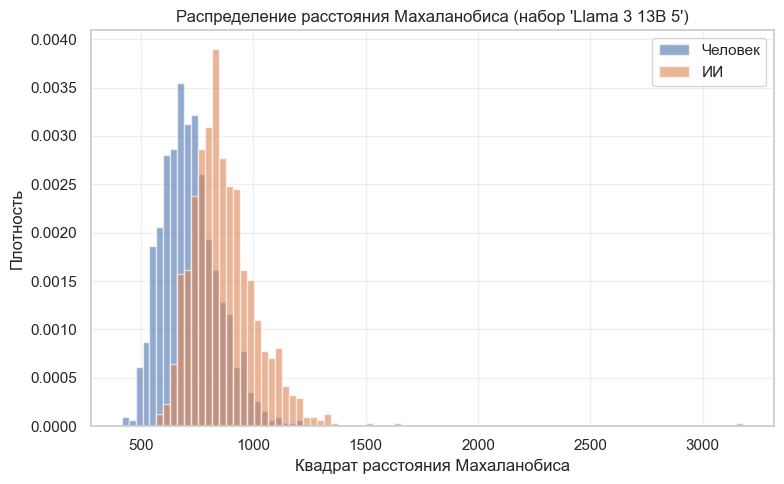

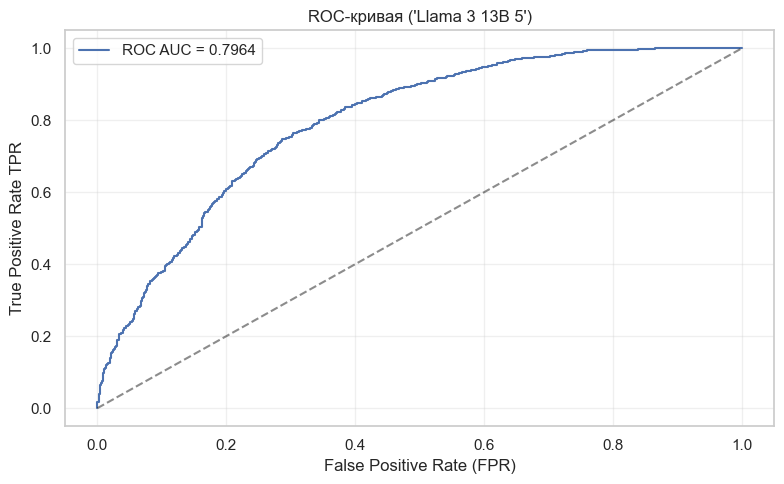

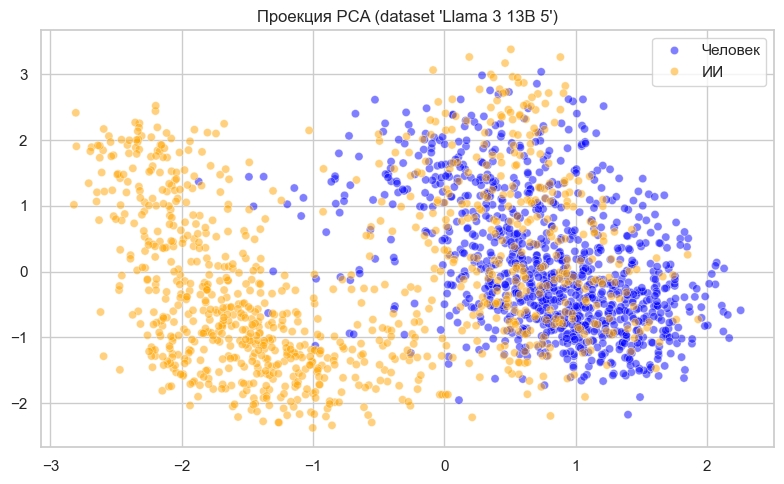


Набор: DeepSeek V3.2 1
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [02:16<00:00,  1.38it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     716.9718
Стд. отклонение    |                     128.0190
Асимметрия         |                       0.9367
Эксцесс            |                       2.3939
95% квантиль       |                     946.0870
99% квантиль       |                    1095.6206

Статистики расстояния Махаланобиса (ии)
Среднее            |                     870.2755
Стд. отклонение    |                     139.9945
Асимметрия         |                       1.1469
Эксцесс            |                       2.6945
95% квантиль       |                    1123.9907
99% квантиль       |                    1309.5471

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.8079
PR-AUC                             : 0.7714


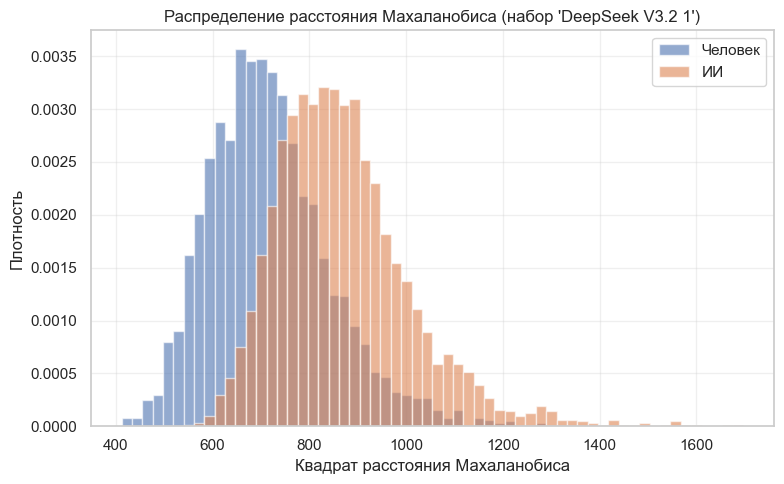

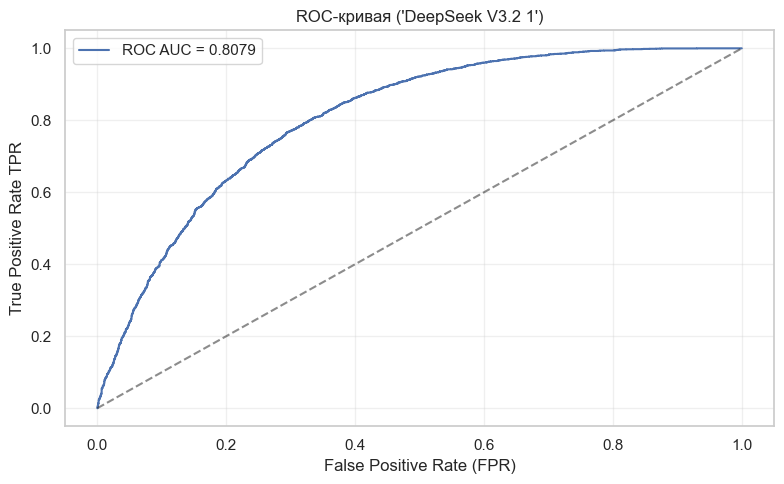

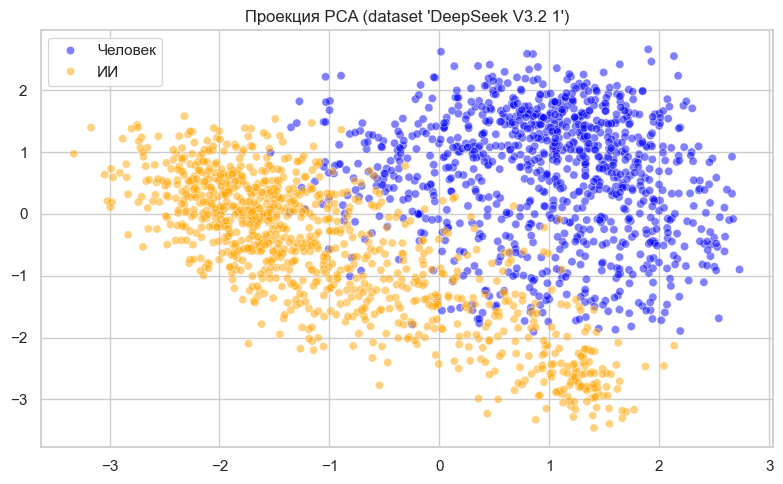


Набор: DeepSeek V3.2 2
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [02:18<00:00,  1.36it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     716.9718
Стд. отклонение    |                     128.0190
Асимметрия         |                       0.9367
Эксцесс            |                       2.3939
95% квантиль       |                     946.0870
99% квантиль       |                    1095.6206

Статистики расстояния Махаланобиса (ии)
Среднее            |                     806.7632
Стд. отклонение    |                     114.1152
Асимметрия         |                       0.7056
Эксцесс            |                       0.8630
95% квантиль       |                    1008.4822
99% квантиль       |                    1131.2491

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.7153
PR-AUC                             : 0.6589


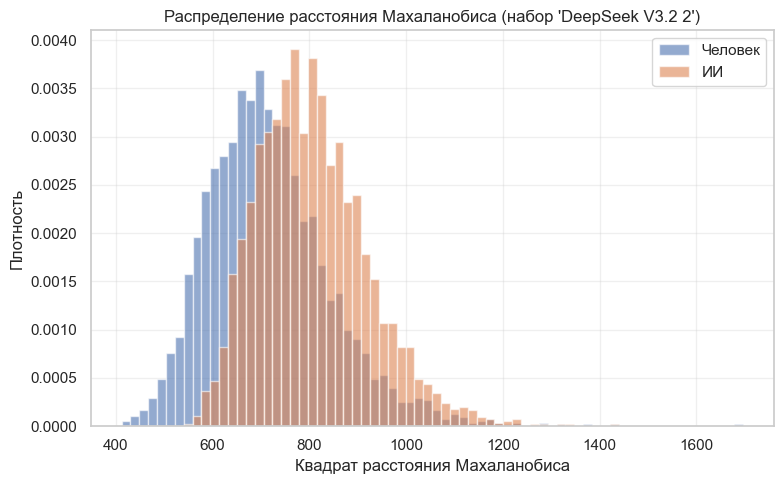

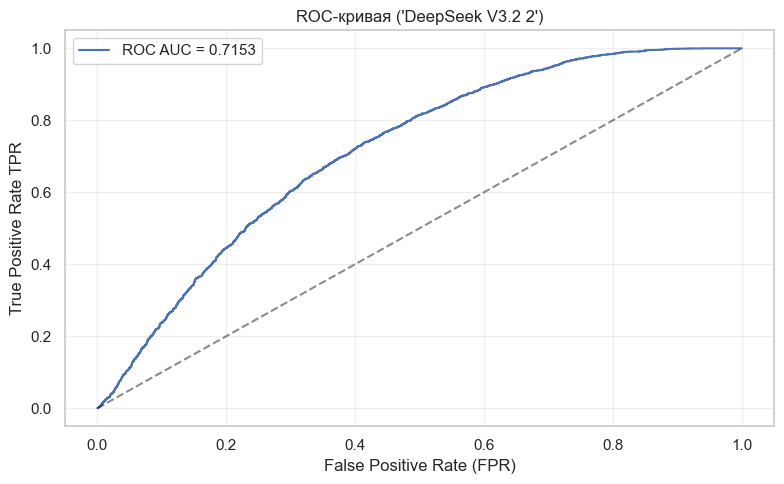

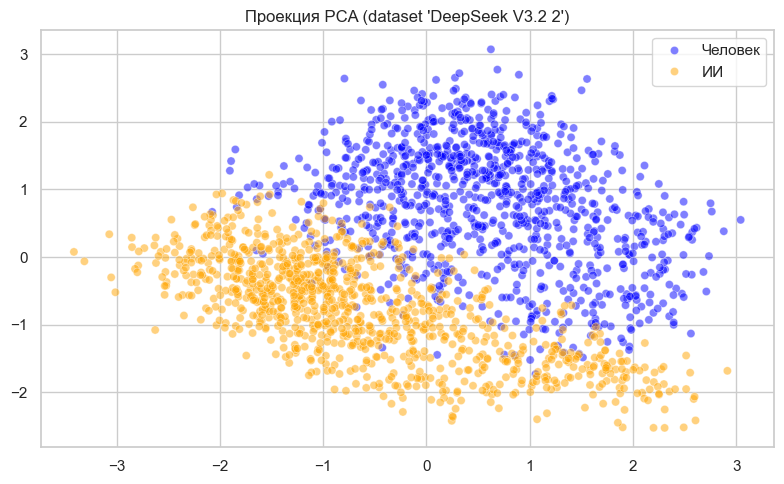


Набор: DeepSeek V3.2 3
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [02:19<00:00,  1.34it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     716.9738
Стд. отклонение    |                     128.0403
Асимметрия         |                       0.9365
Эксцесс            |                       2.3921
95% квантиль       |                     946.1069
99% квантиль       |                    1095.6617

Статистики расстояния Махаланобиса (ии)
Среднее            |                     874.1448
Стд. отклонение    |                     152.0142
Асимметрия         |                       1.2685
Эксцесс            |                       3.3490
95% квантиль       |                    1143.3777
99% квантиль       |                    1363.3249

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2999
ROC-AUC                            : 0.8028
PR-AUC                             : 0.7749


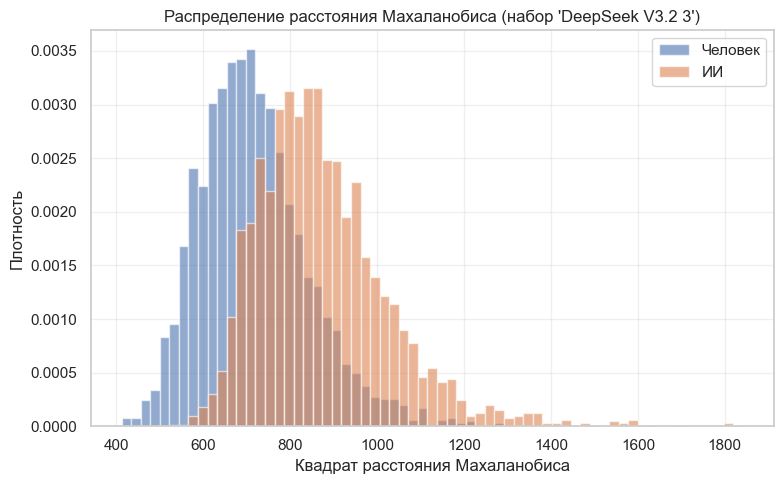

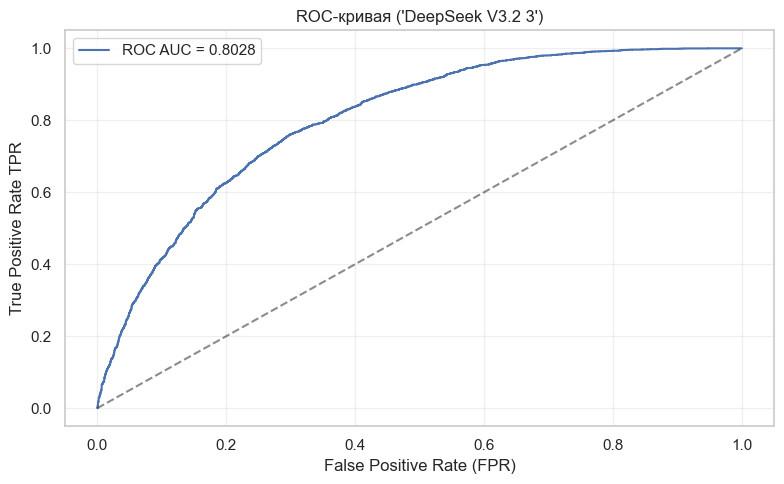

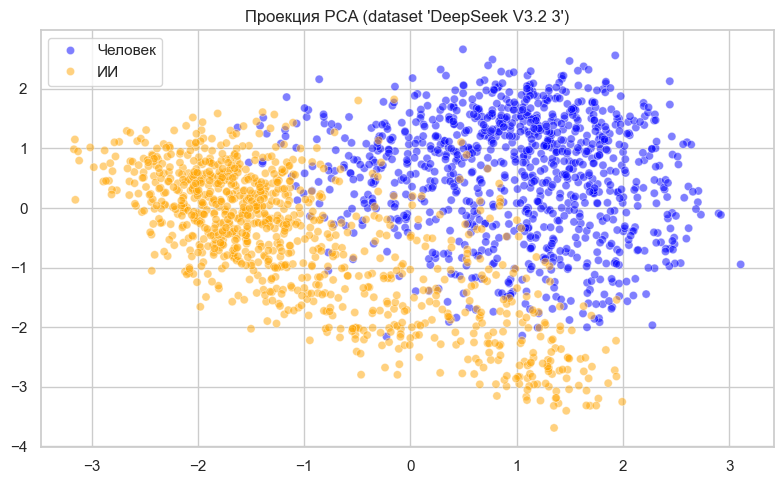


Набор: DeepSeek V3.2 4
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [02:21<00:00,  1.33it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     716.9718
Стд. отклонение    |                     128.0190
Асимметрия         |                       0.9367
Эксцесс            |                       2.3939
95% квантиль       |                     946.0870
99% квантиль       |                    1095.6206

Статистики расстояния Махаланобиса (ии)
Среднее            |                     824.3588
Стд. отклонение    |                     137.4833
Асимметрия         |                       1.0601
Эксцесс            |                       2.2796
95% квантиль       |                    1068.3083
99% квантиль       |                    1246.9594

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.7287
PR-AUC                             : 0.6949


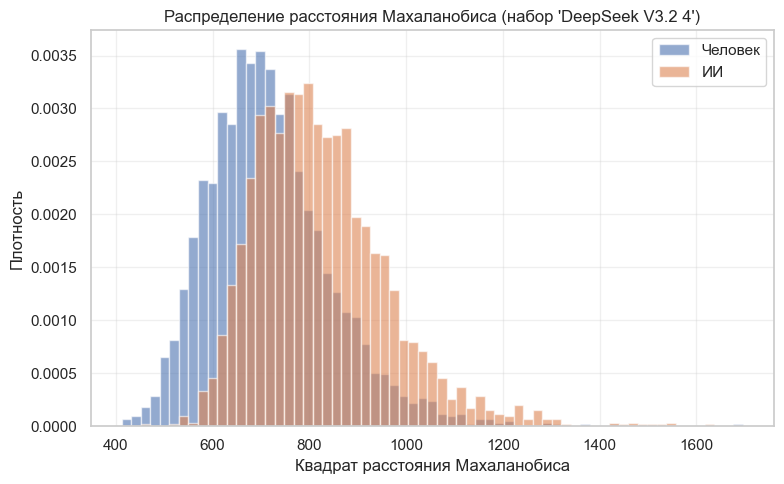

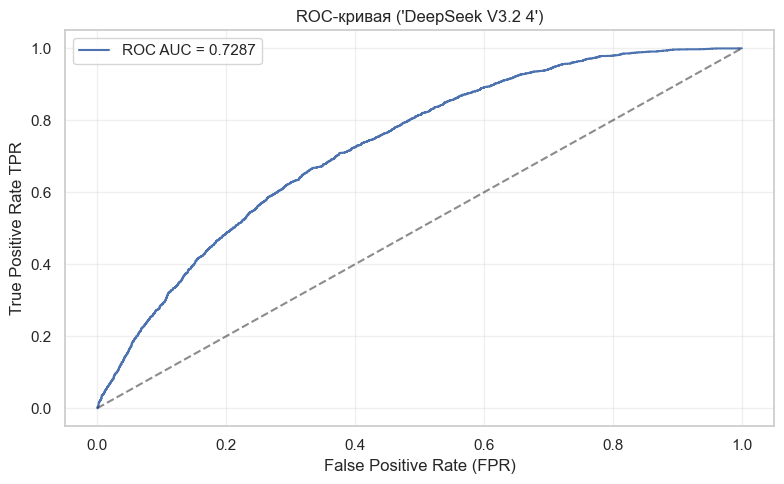

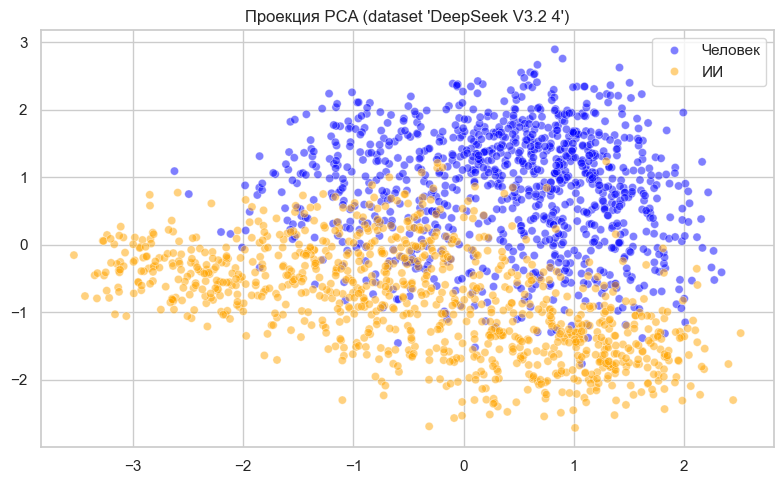


Набор: DeepSeek V3.2 5
----------------------------------------


100%|█████████████████████████████████████████| 188/188 [02:20<00:00,  1.34it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     716.9718
Стд. отклонение    |                     128.0190
Асимметрия         |                       0.9367
Эксцесс            |                       2.3939
95% квантиль       |                     946.0870
99% квантиль       |                    1095.6206

Статистики расстояния Махаланобиса (ии)
Среднее            |                     869.6952
Стд. отклонение    |                     117.7469
Асимметрия         |                       0.7476
Эксцесс            |                       1.2471
95% квантиль       |                    1079.6516
99% квантиль       |                    1206.2758

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 3000
ROC-AUC                            : 0.8246
PR-AUC                             : 0.7728


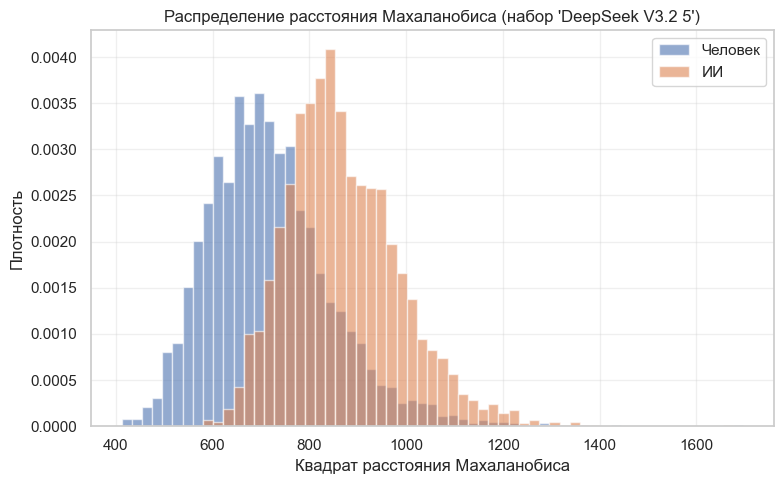

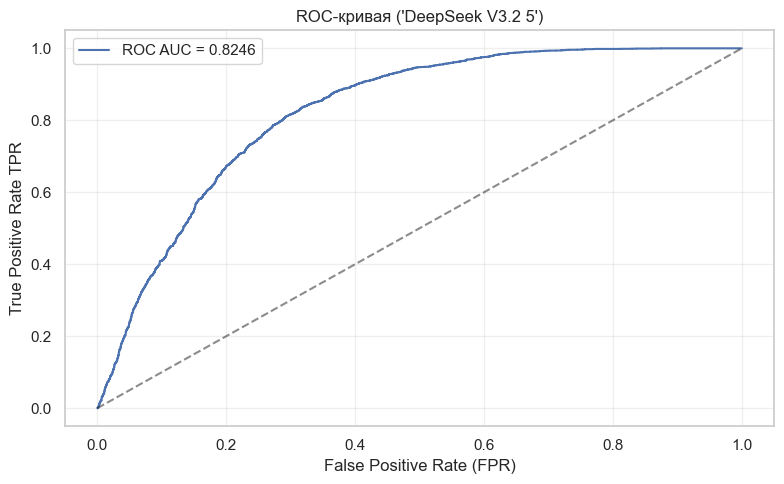

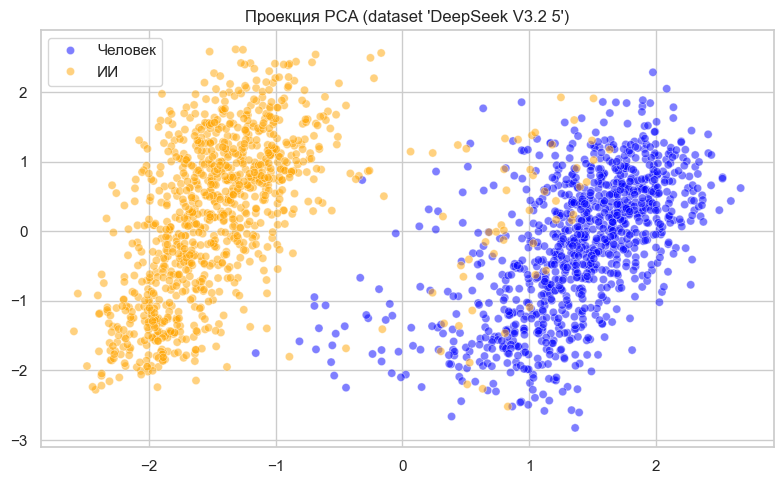


Набор: ChatGPT 1
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [01:34<00:00,  1.32it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     717.6710
Стд. отклонение    |                     128.0606
Асимметрия         |                       0.9079
Эксцесс            |                       2.4785
95% квантиль       |                     950.5082
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     883.5573
Стд. отклонение    |                     168.0162
Асимметрия         |                       2.7533
Эксцесс            |                      23.9057
95% квантиль       |                    1155.6417
99% квантиль       |                    1393.5753

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.8082
PR-AUC                             : 0.7866


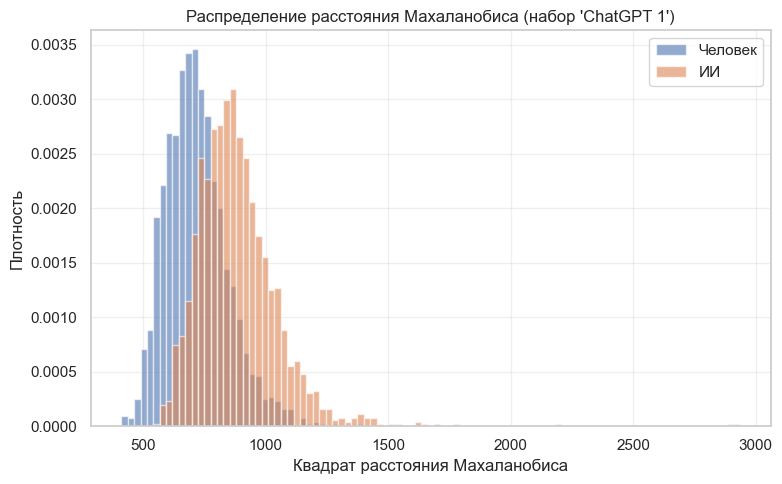

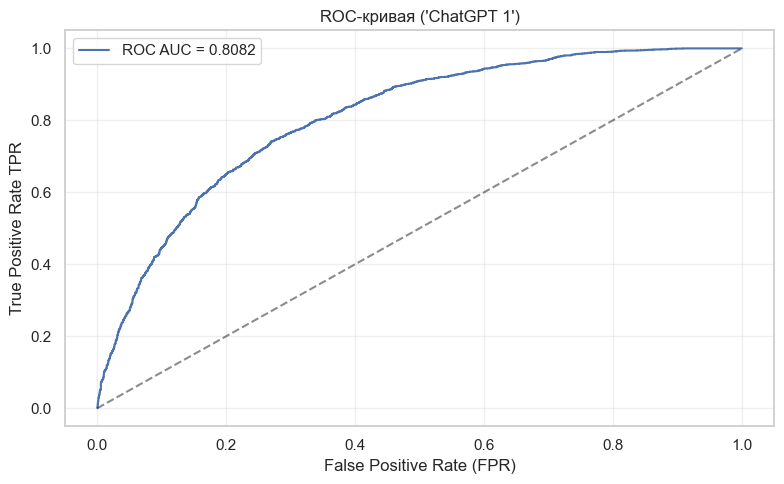

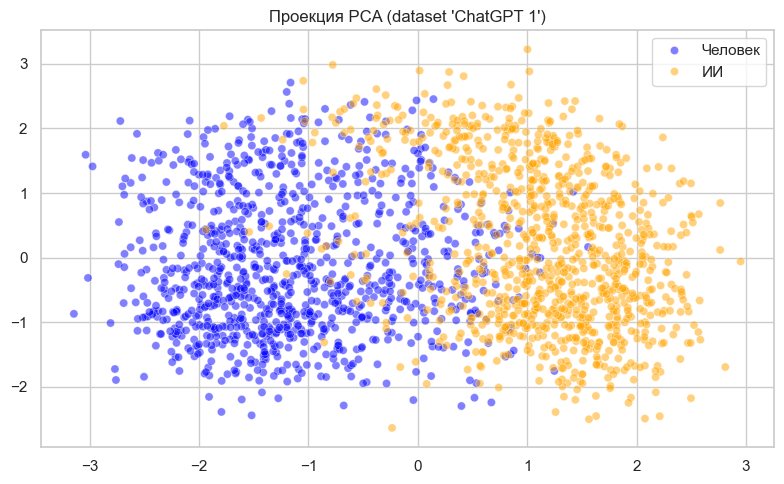


Набор: ChatGPT 2
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [01:33<00:00,  1.33it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     717.6710
Стд. отклонение    |                     128.0606
Асимметрия         |                       0.9079
Эксцесс            |                       2.4785
95% квантиль       |                     950.5082
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     813.4717
Стд. отклонение    |                     118.2420
Асимметрия         |                       0.7076
Эксцесс            |                       0.8514
95% квантиль       |                    1031.5943
99% квантиль       |                    1150.2406

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.7224
PR-AUC                             : 0.6721


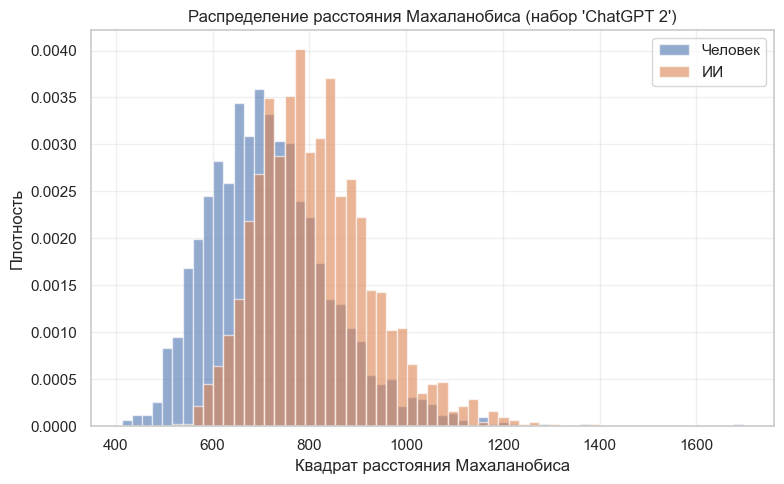

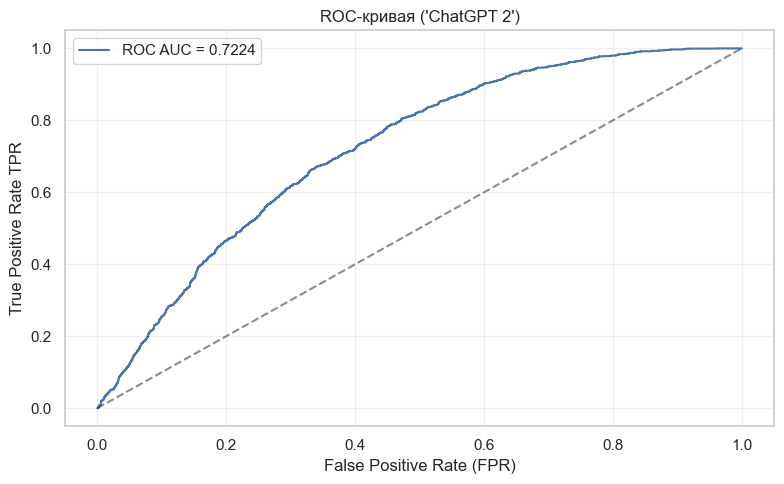

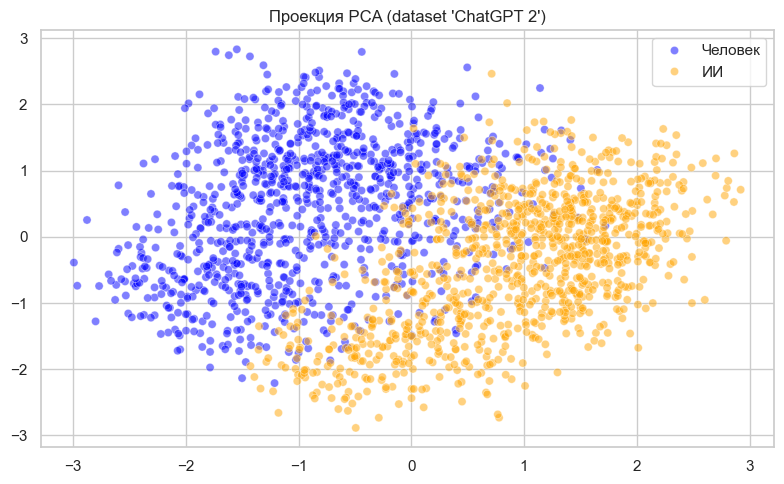


Набор: ChatGPT 3
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [01:34<00:00,  1.32it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     717.6710
Стд. отклонение    |                     128.0606
Асимметрия         |                       0.9079
Эксцесс            |                       2.4785
95% квантиль       |                     950.5082
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     868.5688
Стд. отклонение    |                     156.8391
Асимметрия         |                       1.0942
Эксцесс            |                       2.6990
95% квантиль       |                    1136.6463
99% квантиль       |                    1389.4296

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.7861
PR-AUC                             : 0.7667


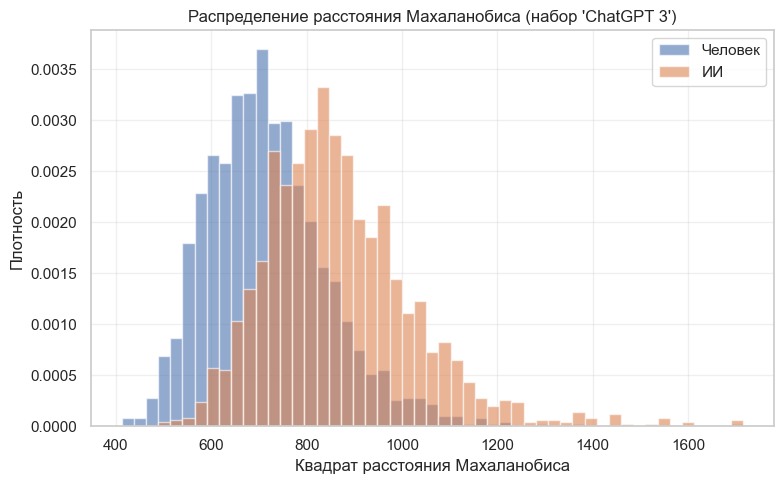

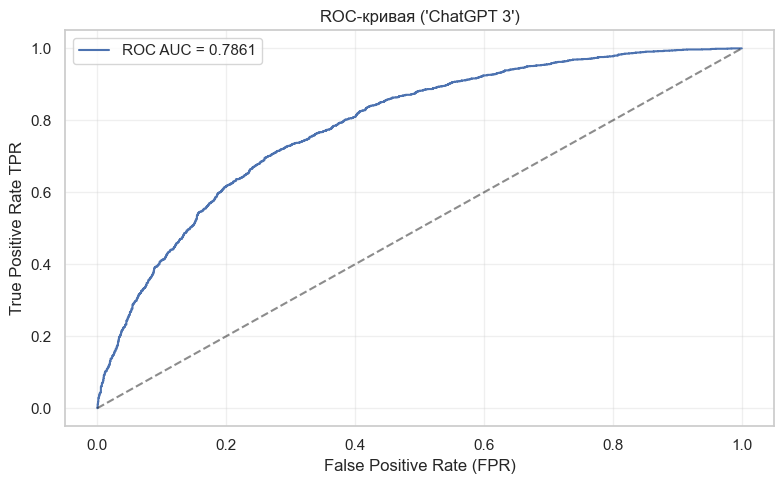

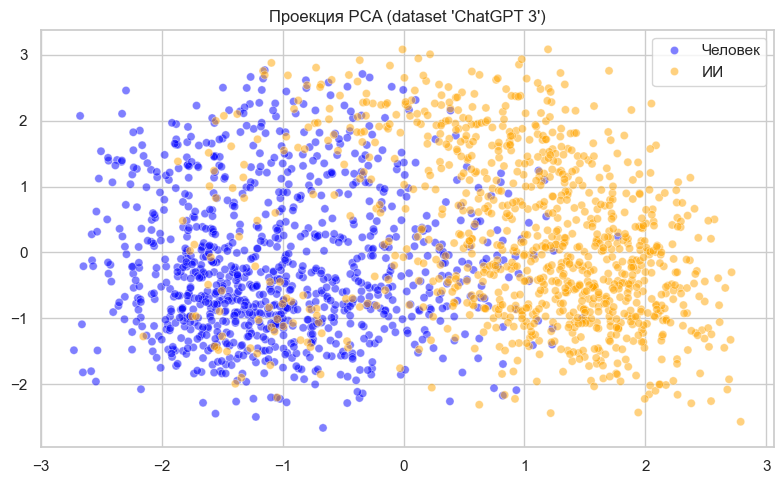


Набор: ChatGPT 4
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [01:36<00:00,  1.30it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     717.6710
Стд. отклонение    |                     128.0606
Асимметрия         |                       0.9079
Эксцесс            |                       2.4785
95% квантиль       |                     950.5082
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     813.2023
Стд. отклонение    |                     181.5055
Асимметрия         |                       5.6699
Эксцесс            |                      85.9698
95% квантиль       |                    1073.2787
99% квантиль       |                    1339.6936

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.6879
PR-AUC                             : 0.6691


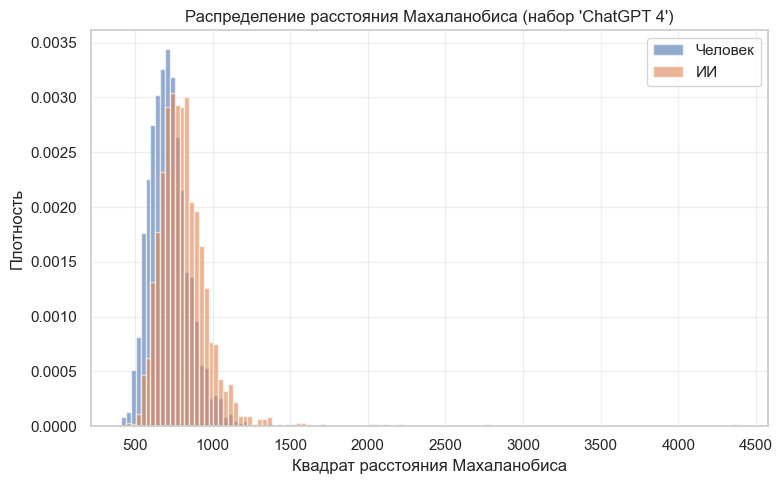

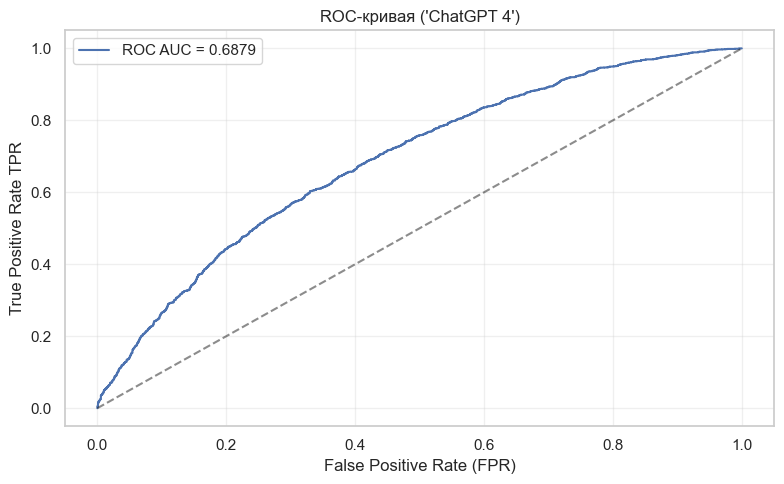

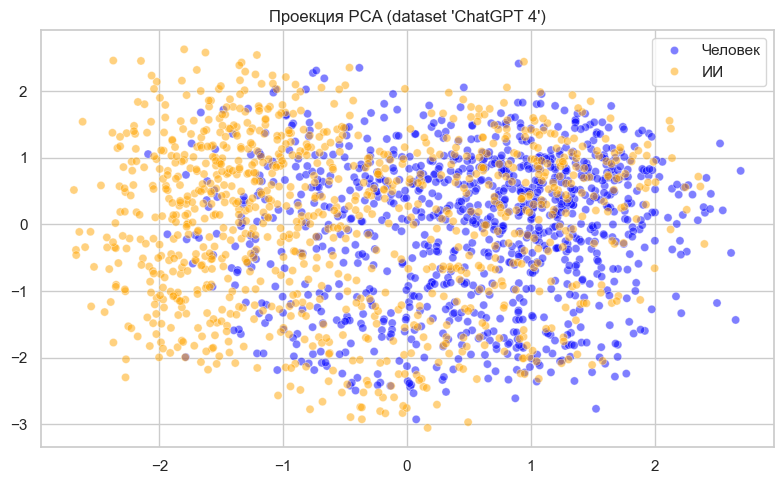


Набор: ChatGPT 5
----------------------------------------


100%|█████████████████████████████████████████| 125/125 [01:32<00:00,  1.34it/s]


Статистики расстояния Махаланобиса (человек)
Среднее            |                     717.6710
Стд. отклонение    |                     128.0606
Асимметрия         |                       0.9079
Эксцесс            |                       2.4785
95% квантиль       |                     950.5082
99% квантиль       |                    1076.8776

Статистики расстояния Махаланобиса (ии)
Среднее            |                     867.0340
Стд. отклонение    |                     125.5110
Асимметрия         |                       1.0376
Эксцесс            |                       3.7494
95% квантиль       |                    1087.2186
99% квантиль       |                    1199.3113

Количество объектов в 0 классе     : 3000
Количество объектов в 1 классе     : 2000
ROC-AUC                            : 0.8125
PR-AUC                             : 0.7681


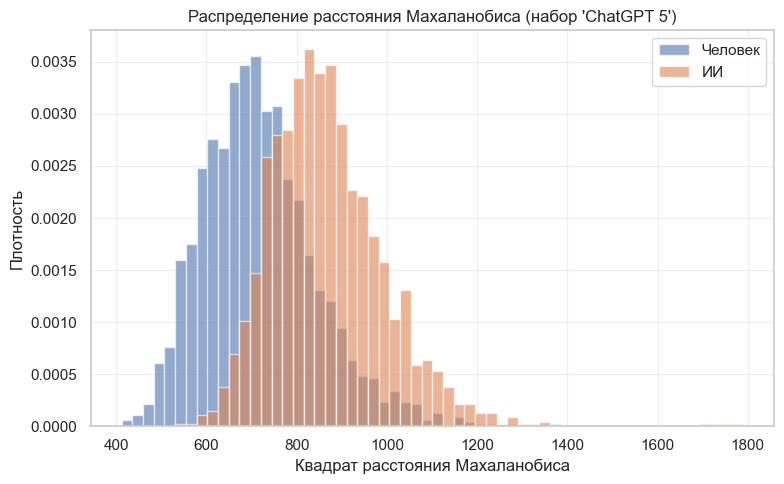

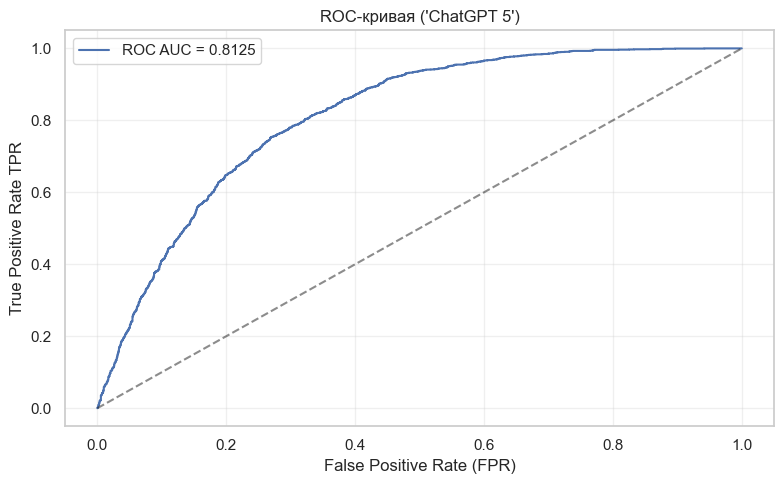

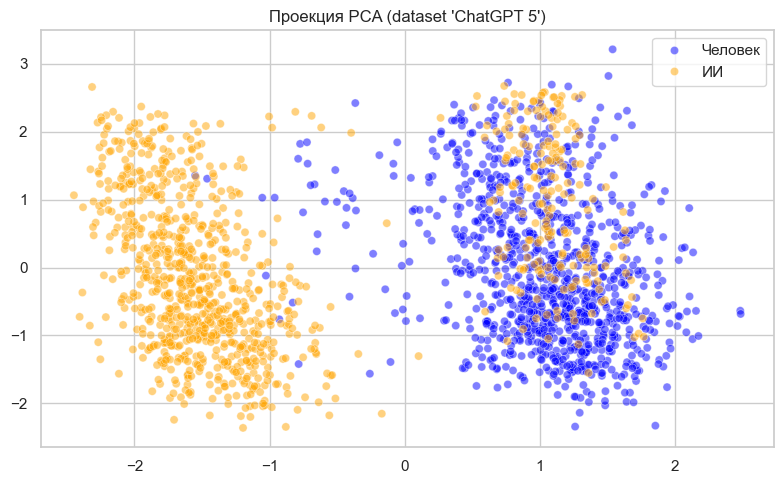

In [7]:
results = []

print_header(f"ENCODER: {ENCODER}")

tokenizer = AutoTokenizer.from_pretrained(ENCODER)
model = AutoModel.from_pretrained(ENCODER)

X_human = get_embeddings(tokenizer, model, human_df["text"])
X_human = X_human.numpy().astype(np.float32)

print_norm_stats(X_human)

X_h_train, X_h_test = train_test_split(
    X_human,
    test_size=0.3,
    random_state=SEED
)

print_kv("Эмбеддинги живых текстов (train)", len(X_h_train))
print_kv("Эмбеддинги живых текстов (test)", len(X_h_test))

cov = LedoitWolf().fit(X_h_train)
scores_h_train = cov.mahalanobis(X_h_train)

covariance_spectrum(cov)

for name, ai_df in ai_datasets.items():
    print(f"\nНабор: {name}")
    print("-" * 40)

    X_ai = get_embeddings(tokenizer, model, ai_df["text"])
    X_ai = X_ai.numpy().astype(np.float32)

    n = min(len(X_h_test), len(X_ai))

    X_test = np.vstack([X_h_test[:n], X_ai[:n]])
    y_test = np.concatenate([
        np.zeros(n, dtype=int),
        np.ones(n, dtype=int)
    ])

    scores = cov.mahalanobis(X_test)
    scores_human = scores[:n]
    scores_ai = scores[n:]

    print_mahalanobis_stats(scores_human, "человек")
    print_mahalanobis_stats(scores_ai, "ии")

    roc_auc = roc_auc_score(y_test, scores)
    ap = average_precision_score(y_test, scores)

    print_kv("Количество объектов в 0 классе", len(X_h_test))
    print_kv("Количество объектов в 1 классе", len(X_ai))
    print_kv("ROC-AUC", f"{roc_auc:.4f}")
    print_kv("PR-AUC", f"{ap:.4f}")

    plot_mahalanobis_distributions(scores_human, scores_ai, name)
    plot_roc_curve(y_test, scores, roc_auc, name)
    plot_pca_projection(X_h_test, X_ai, name)

    results.append({
        "dataset": name,
        "size": len(X_test),
        "roc_auc": roc_auc,
        "pr_auc": ap
    })

In [8]:
results_df = pd.DataFrame(results)
print(results_df)

            dataset  size   roc_auc    pr_auc
0      Mistral 7B 1  3000  0.799181  0.788520
1      Mistral 7B 2  3000  0.729771  0.707121
2      Mistral 7B 3  3000  0.759154  0.749231
3      Mistral 7B 4  3000  0.743086  0.726029
4      Mistral 7B 5  3000  0.714425  0.666368
5     Llama 3 13B 1  1998  0.854843  0.849935
6     Llama 3 13B 2  2000  0.774838  0.752128
7     Llama 3 13B 3  1988  0.822950  0.823949
8     Llama 3 13B 4  1994  0.788499  0.781455
9     Llama 3 13B 5  1998  0.796416  0.770426
10  DeepSeek V3.2 1  6000  0.807908  0.771368
11  DeepSeek V3.2 2  6000  0.715305  0.658937
12  DeepSeek V3.2 3  5998  0.802802  0.774936
13  DeepSeek V3.2 4  6000  0.728727  0.694933
14  DeepSeek V3.2 5  6000  0.824615  0.772799
15        ChatGPT 1  4000  0.808193  0.786640
16        ChatGPT 2  4000  0.722435  0.672098
17        ChatGPT 3  4000  0.786131  0.766696
18        ChatGPT 4  4000  0.687877  0.669090
19        ChatGPT 5  4000  0.812501  0.768139
